In [ ]:
# ============================================================================
# FORTUM HACKATHON - COMPLETE DATA PREPARATION PIPELINE
# ============================================================================
# Step 1: Install Required Libraries
# ============================================================================
!pip install holidays astral openpyxl -q



In [ ]:
# ============================================================================
# Step 2: Import Libraries
# ============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import holidays
import requests
from astral import LocationInfo
from astral.sun import sun
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("✅ Libraries imported successfully!")


✅ Libraries imported successfully!


In [ ]:
# ============================================================================
# Step 3: Upload Your Files to Colab
# ============================================================================
#from google.colab import files

print("📂 Please upload your files:")
print("1. 20251111_JUNCTION_training.xlsx")
print("2. 20251111_JUNCTION_example_hourly.csv (optional - for format reference)")
print("3. 20251111_JUNCTION_example_monthly.csv (optional - for format reference)")

#uploaded = files.upload()


📂 Please upload your files:
1. 20251111_JUNCTION_training.xlsx
2. 20251111_JUNCTION_example_hourly.csv (optional - for format reference)
3. 20251111_JUNCTION_example_monthly.csv (optional - for format reference)


In [ ]:
# ============================================================================
# Step 4: Load Data
# ============================================================================
print("\n" + "="*80)
print("LOADING DATA")
print("="*80)

# Load training data
training_file = '20251111_JUNCTION_training.xlsx'
print(f"📖 Loading {training_file}...")

root = '/content/drive/MyDrive/Junction2025/datasets/'

# Load consumption data (with European format)
consumption_df = pd.read_excel(
    root+training_file,
    sheet_name='training_consumption',
    decimal=',',  # European decimal separator
)

# Load price data
prices_df = pd.read_excel(
    root+training_file,
    sheet_name='training_prices',
    decimal=','
)

# Load groups metadata
groups_df = pd.read_excel(
    root+training_file,
    sheet_name='groups'
)

print(f"✅ Consumption data: {consumption_df.shape}")
print(f"✅ Price data: {prices_df.shape}")
print(f"✅ Groups metadata: {groups_df.shape}")



LOADING DATA
📖 Loading 20251111_JUNCTION_training.xlsx...
✅ Consumption data: (32856, 113)
✅ Price data: (32880, 2)
✅ Groups metadata: (112, 2)


In [ ]:
#consumption_df
consumption_df.columns

Index(['measured_at',            28,            29,            30,
                  36,            37,            38,            39,
                  40,            41,
       ...
                 697,           698,           705,           706,
                 707,           708,           709,           738,
                 740,           741],
      dtype='object', length=113)

In [ ]:
prices_df.columns

Index(['measured_at', 'eur_per_mwh'], dtype='object')

In [ ]:
groups_df.columns

Index(['group_id', 'group_label '], dtype='object')

In [ ]:
groups_df

,group_id,group_label
0,28,Eastern Finland | Etelä-Savo | Etelä-Savo | Pr...
1,29,Eastern Finland | Etelä-Savo | Etelä-Savo | Pr...
2,30,Eastern Finland | Etelä-Savo | Etelä-Savo | Pr...
3,36,Eastern Finland | Pohjois-Karjala | Joensuu | ...
4,37,Eastern Finland | Pohjois-Karjala | Joensuu | ...
...,...,...
107,708,Western and Inland Finland | Pirkanmaa | Tampe...
108,709,Western and Inland Finland | Pirkanmaa | Tampe...
109,738,Western and Inland Finland | Pohjanmaa | Pohja...
110,740,Western and Inland Finland | Pohjanmaa | Pohja...


In [ ]:
# how many '|' are there in each row
groups_df['group_label'].str.count('\|').value_counts()

,count
group_label,
5,112


In [ ]:
# ============================================================================
# Step 5: Parse Groups Metadata
# ============================================================================
print("\n" + "="*80)
print("PARSING GROUP METADATA")
print("="*80)

# Clean column names by stripping whitespace
groups_df.columns = groups_df.columns.str.strip()

# Parse the group_label column (format: "Region | County | Municipality | Segment | Product | Bucket")
groups_df[['macro_region', 'county', 'municipality', 'segment', 'product_type', 'consumption_bucket']] = \
    groups_df['group_label'].str.split('\|', expand=True)

print("✅ Group attributes parsed:")
print(f"   - Macro regions: {groups_df['macro_region'].nunique()}")
print(f"   - Counties: {groups_df['county'].nunique()}")
print(f"   - Municipalities: {groups_df['municipality'].nunique()}")
print(f"   - Segments: {groups_df['segment'].unique()}")
print(f"   - Product types: {groups_df['product_type'].unique()}")
print(f"   - Consumption buckets: {groups_df['consumption_bucket'].unique()}")

# Display sample
print("\n📋 Sample groups:")
print(groups_df[['group_id', 'macro_region', 'municipality', 'segment', 'product_type']].head())


PARSING GROUP METADATA
✅ Group attributes parsed:
   - Macro regions: 6
   - Counties: 15
   - Municipalities: 30
   - Segments: [' Private ' ' Enterprise ']
   - Product types: [' Spot Price ' ' Variable Price ' ' Fixed Price ' ' Flat/Hybrid '
 ' Portfolio ']
   - Consumption buckets: [' High' ' Low' ' Medium']

📋 Sample groups:
   group_id      macro_region  municipality       segment      product_type
0        28  Eastern Finland    Etelä-Savo       Private        Spot Price 
1        29  Eastern Finland    Etelä-Savo       Private        Spot Price 
2        30  Eastern Finland    Etelä-Savo       Private        Spot Price 
3        36  Eastern Finland       Joensuu    Enterprise    Variable Price 
4        37  Eastern Finland       Joensuu       Private       Fixed Price 


In [ ]:
# trim the spaces start and end for all coulumns values
groups_df = groups_df.apply(lambda x: x.str.strip() if x.dtype == "object" else x)

In [ ]:
# ============================================================================
# Step 6: Transform Data from Wide to Long Format
# ============================================================================
print("\n" + "="*80)
print("TRANSFORMING DATA TO LONG FORMAT")
print("="*80)

# Convert consumption data from wide to long format
# Wide format: each column is a group
# Long format: one row per timestamp per group

print("🔄 Transforming consumption data...")
consumption_long = consumption_df.melt(
    id_vars=['measured_at'],
    var_name='group_id',
    value_name='consumption'
)

# Convert group_id to integer
consumption_long['group_id'] = consumption_long['group_id'].astype(int)

# Convert measured_at to datetime
consumption_long['measured_at'] = pd.to_datetime(consumption_long['measured_at'])

# Sort by group and time
consumption_long = consumption_long.sort_values(['group_id', 'measured_at']).reset_index(drop=True)

print(f"✅ Transformed shape: {consumption_long.shape}")
print(f"✅ Date range: {consumption_long['measured_at'].min()} to {consumption_long['measured_at'].max()}")
print(f"✅ Number of groups: {consumption_long['group_id'].nunique()}")

# Display sample
print("\n📋 Sample data:")
print(consumption_long.head(10))



TRANSFORMING DATA TO LONG FORMAT
🔄 Transforming consumption data...
✅ Transformed shape: (3679872, 3)
✅ Date range: 2021-01-01 00:00:00+00:00 to 2024-09-30 23:00:00+00:00
✅ Number of groups: 112

📋 Sample data:
                measured_at  group_id  consumption
0 2021-01-01 00:00:00+00:00        28     7.010736
1 2021-01-01 01:00:00+00:00        28     6.600845
2 2021-01-01 02:00:00+00:00        28     6.468329
3 2021-01-01 03:00:00+00:00        28     6.712097
4 2021-01-01 04:00:00+00:00        28     6.418159
5 2021-01-01 05:00:00+00:00        28     6.255508
6 2021-01-01 06:00:00+00:00        28     6.438720
7 2021-01-01 07:00:00+00:00        28     6.936695
8 2021-01-01 08:00:00+00:00        28     7.240114
9 2021-01-01 09:00:00+00:00        28     7.191511


In [ ]:
# ============================================================================
# Step 7: Basic Data Quality Checks
# ============================================================================
print("\n" + "="*80)
print("DATA QUALITY CHECKS")
print("="*80)

# Check for missing values
missing_consumption = consumption_long['consumption'].isna().sum()
print(f"❓ Missing consumption values: {missing_consumption} ({missing_consumption/len(consumption_long)*100:.2f}%)")

# Check for negative values
negative_consumption = (consumption_long['consumption'] < 0).sum()
print(f"⚠️  Negative consumption values: {negative_consumption}")

# Check for zeros
zero_consumption = (consumption_long['consumption'] == 0).sum()
print(f"⚠️  Zero consumption values: {zero_consumption} ({zero_consumption/len(consumption_long)*100:.2f}%)")

# Statistics
print("\n📊 Consumption Statistics:")
print(consumption_long['consumption'].describe())



DATA QUALITY CHECKS
❓ Missing consumption values: 0 (0.00%)
⚠️  Negative consumption values: 0
⚠️  Zero consumption values: 0 (0.00%)

📊 Consumption Statistics:
count    3.679872e+06
mean     1.007347e+00
std      1.591174e+00
min      5.216955e-02
25%      2.233347e-01
50%      4.705880e-01
75%      9.525849e-01
max      1.813508e+01
Name: consumption, dtype: float64


In [ ]:
# ============================================================================
# Step 8: Merge with Price Data
# ============================================================================
print("\n" + "="*80)
print("MERGING PRICE DATA")
print("="*80)

# Prepare price data
prices_df['measured_at'] = pd.to_datetime(prices_df['measured_at'])

# Merge consumption with prices
df = consumption_long.merge(
    prices_df[['measured_at', 'eur_per_mwh']],
    on='measured_at',
    how='left'
)

print(f"✅ Merged data shape: {df.shape}")
print(f"❓ Missing price values: {df['eur_per_mwh'].isna().sum()}")



MERGING PRICE DATA
✅ Merged data shape: (3679872, 4)
❓ Missing price values: 0


In [ ]:
# rows having missing values
df[df['eur_per_mwh'].isna()]

,measured_at,group_id,consumption,eur_per_mwh


In [ ]:
# ============================================================================
# Step 9: Merge with Group Metadata
# ============================================================================
print("\n" + "="*80)
print("MERGING GROUP METADATA")
print("="*80)

# Merge with group metadata
df = df.merge(
    groups_df[['group_id', 'macro_region', 'county', 'municipality',
               'segment', 'product_type', 'consumption_bucket']],
    on='group_id',
    how='left'
)

print(f"✅ Final merged data shape: {df.shape}")
print(f"\n📋 Columns in dataset:")
print(df.columns.tolist())



MERGING GROUP METADATA
✅ Final merged data shape: (3679872, 10)

📋 Columns in dataset:
['measured_at', 'group_id', 'consumption', 'eur_per_mwh', 'macro_region', 'county', 'municipality', 'segment', 'product_type', 'consumption_bucket']


In [ ]:
# ============================================================================
# Step 10: Create Time Features
# ============================================================================
print("\n" + "="*80)
print("CREATING TIME FEATURES")
print("="*80)

# Extract time components
df['year'] = df['measured_at'].dt.year
df['month'] = df['measured_at'].dt.month
df['day'] = df['measured_at'].dt.day
df['hour'] = df['measured_at'].dt.hour
df['day_of_week'] = df['measured_at'].dt.dayofweek  # 0=Monday, 6=Sunday
df['day_of_year'] = df['measured_at'].dt.dayofyear
df['week_of_year'] = df['measured_at'].dt.isocalendar().week

# Binary features
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
df['is_night'] = ((df['hour'] >= 22) | (df['hour'] <= 6)).astype(int)

# Cyclical encoding for hour (captures that hour 23 and hour 0 are close)
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

# Cyclical encoding for day of week
df['dow_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['dow_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)

# Cyclical encoding for month
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

# Season (meteorological)
df['season'] = df['month'].apply(lambda x:
    0 if x in [12, 1, 2] else  # Winter
    1 if x in [3, 4, 5] else    # Spring
    2 if x in [6, 7, 8] else    # Summer
    3                           # Fall
)

print("✅ Time features created:")
print(df[['measured_at', 'year', 'month', 'day', 'hour', 'day_of_week',
          'is_weekend', 'hour_sin', 'season']].head())


CREATING TIME FEATURES
✅ Time features created:
                measured_at  year  month  day  hour  day_of_week  is_weekend  \
0 2021-01-01 00:00:00+00:00  2021      1    1     0            4           0   
1 2021-01-01 01:00:00+00:00  2021      1    1     1            4           0   
2 2021-01-01 02:00:00+00:00  2021      1    1     2            4           0   
3 2021-01-01 03:00:00+00:00  2021      1    1     3            4           0   
4 2021-01-01 04:00:00+00:00  2021      1    1     4            4           0   

   hour_sin  season  
0  0.000000       0  
1  0.258819       0  
2  0.500000       0  
3  0.707107       0  
4  0.866025       0  


In [ ]:
# ============================================================================
# Step 11: Add Finnish Holidays
# ============================================================================
print("\n" + "="*80)
print("ADDING FINNISH HOLIDAYS")
print("="*80)

# Get Finnish holidays
fi_holidays = holidays.Finland(years=range(2021, 2026))

# Check if date is a holiday
df['is_holiday'] = df['measured_at'].dt.date.apply(lambda x: x in fi_holidays).astype(int)

# Get holiday name (for analysis)
df['holiday_name'] = df['measured_at'].dt.date.apply(
    lambda x: fi_holidays.get(x, '')
)

print(f"✅ Total holiday hours: {df['is_holiday'].sum()}")
print(f"\n📅 Holidays in dataset:")
holiday_dates = df[df['is_holiday'] == 1][['measured_at', 'holiday_name']].drop_duplicates()
print(holiday_dates.head(20))



ADDING FINNISH HOLIDAYS
✅ Total holiday hours: 147840

📅 Holidays in dataset:
                 measured_at    holiday_name
0  2021-01-01 00:00:00+00:00  New Year's Day
1  2021-01-01 01:00:00+00:00  New Year's Day
2  2021-01-01 02:00:00+00:00  New Year's Day
3  2021-01-01 03:00:00+00:00  New Year's Day
4  2021-01-01 04:00:00+00:00  New Year's Day
5  2021-01-01 05:00:00+00:00  New Year's Day
6  2021-01-01 06:00:00+00:00  New Year's Day
7  2021-01-01 07:00:00+00:00  New Year's Day
8  2021-01-01 08:00:00+00:00  New Year's Day
9  2021-01-01 09:00:00+00:00  New Year's Day
10 2021-01-01 10:00:00+00:00  New Year's Day
11 2021-01-01 11:00:00+00:00  New Year's Day
12 2021-01-01 12:00:00+00:00  New Year's Day
13 2021-01-01 13:00:00+00:00  New Year's Day
14 2021-01-01 14:00:00+00:00  New Year's Day
15 2021-01-01 15:00:00+00:00  New Year's Day
16 2021-01-01 16:00:00+00:00  New Year's Day
17 2021-01-01 17:00:00+00:00  New Year's Day
18 2021-01-01 18:00:00+00:00  New Year's Day
19 2021-01-01 19:00:0

In [ ]:
# ============================================================================
# Step 12: Calculate Daylight Hours for Finland
# ============================================================================
print("\n" + "="*80)
print("CALCULATING DAYLIGHT HOURS")
print("="*80)

def get_daylight_hours(date, latitude=60.1695, longitude=24.9354):
    """Calculate daylight hours for a given date in Finland (using Helsinki coordinates)"""
    try:
        city = LocationInfo("Helsinki", "Finland", "Europe/Helsinki", latitude, longitude)
        s = sun(city.observer, date=date)
        daylight = (s['sunset'] - s['sunrise']).total_seconds() / 3600
        return round(daylight, 2)
    except:
        return np.nan

# Calculate daylight hours (this might take a minute)
print("⏳ Calculating daylight hours (this may take a minute)...")
unique_dates = df['measured_at'].dt.date.unique()
daylight_dict = {date: get_daylight_hours(date) for date in unique_dates}
df['daylight_hours'] = df['measured_at'].dt.date.map(daylight_dict)

print(f"✅ Daylight hours calculated")
print(f"   - Min: {df['daylight_hours'].min():.2f} hours")
print(f"   - Max: {df['daylight_hours'].max():.2f} hours")


CALCULATING DAYLIGHT HOURS
⏳ Calculating daylight hours (this may take a minute)...
✅ Daylight hours calculated
   - Min: 5.80 hours
   - Max: 18.91 hours


In [ ]:
# ============================================================================
# Step 13: Get Weather Data from Open-Meteo API (BULLETPROOF FIX)
# ============================================================================
print("\n" + "="*80)
print("FETCHING WEATHER DATA FROM OPEN-METEO")
print("="*80)

def get_weather_data(start_date, end_date, lat=60.1695, lon=24.9354):
    """
    Fetch historical weather data from Open-Meteo API
    Default coordinates: Helsinki, Finland
    """
    url = "https://archive-api.open-meteo.com/v1/archive"

    params = {
        "latitude": lat,
        "longitude": lon,
        "start_date": start_date,
        "end_date": end_date,
        "hourly": [
            "temperature_2m",
            "relative_humidity_2m",
            "precipitation",
            "wind_speed_10m",
            "cloud_cover"
        ],
        "timezone": "Europe/Helsinki"
    }

    print(f"   📡 Fetching weather from {start_date} to {end_date}...")
    response = requests.get(url, params=params)

    if response.status_code == 200:
        data = response.json()
        weather_df = pd.DataFrame({
            'measured_at': pd.to_datetime(data['hourly']['time']),
            'temperature': data['hourly']['temperature_2m'],
            'humidity': data['hourly']['relative_humidity_2m'],
            'precipitation': data['hourly']['precipitation'],
            'wind_speed': data['hourly']['wind_speed_10m'],
            'cloud_cover': data['hourly']['cloud_cover']
        })

        return weather_df
    else:
        print(f"   ❌ Error: {response.status_code}")
        return None

# Fetch weather data for training period
start_date = df['measured_at'].min().strftime('%Y-%m-%d')
end_date = df['measured_at'].max().strftime('%Y-%m-%d')

print(f"🌤️  Fetching weather data for Helsinki...")
weather_df = get_weather_data(start_date, end_date)

if weather_df is not None:
    print(f"✅ Weather data fetched: {weather_df.shape}")
    print(f"\n📊 Weather Statistics:")
    print(weather_df.describe())

    # ⭐⭐⭐ BULLETPROOF FIX: Force both to timezone-naive ⭐⭐⭐
    print("\n🔧 Fixing timezone mismatch...")

    # Check current timezone status
    print(f"   df['measured_at'] dtype: {df['measured_at'].dtype}")
    print(f"   weather_df['measured_at'] dtype: {weather_df['measured_at'].dtype}")

    # Remove timezone from weather data if present
    if hasattr(weather_df['measured_at'].dtype, 'tz') and weather_df['measured_at'].dtype.tz is not None:
        print("   Removing timezone from weather data...")
        weather_df['measured_at'] = weather_df['measured_at'].dt.tz_localize(None)

    # Ensure df['measured_at'] is also timezone-naive
    if hasattr(df['measured_at'].dtype, 'tz') and df['measured_at'].dtype.tz is not None:
        print("   Removing timezone from consumption data...")
        df['measured_at'] = df['measured_at'].dt.tz_localize(None)

    # Final check
    print(f"   After fix - df['measured_at'] dtype: {df['measured_at'].dtype}")
    print(f"   After fix - weather_df['measured_at'] dtype: {weather_df['measured_at'].dtype}")

    # Merge weather data
    print("   Merging weather data...")
    df = df.merge(weather_df, on='measured_at', how='left')
    print(f"✅ Weather data merged successfully")

    # Check merge quality
    missing_weather = df['temperature'].isna().sum()
    print(f"❓ Missing weather values after merge: {missing_weather}")

    if missing_weather > 0:
        print(f"   ⚠️  {missing_weather} rows have missing weather data")
        print("   These will be filled in later steps")
else:
    print("⚠️  Could not fetch weather data. Continuing without it...")


FETCHING WEATHER DATA FROM OPEN-METEO
🌤️  Fetching weather data for Helsinki...
   📡 Fetching weather from 2021-01-01 to 2024-09-30...
✅ Weather data fetched: (32856, 6)

📊 Weather Statistics:
               measured_at   temperature      humidity  precipitation  \
count                32856  32856.000000  32856.000000   32856.000000   
mean   2022-11-16 11:30:00      6.596743     83.477751       0.085765   
min    2021-01-01 00:00:00    -18.500000     30.000000       0.000000   
25%    2021-12-09 05:45:00      0.300000     78.000000       0.000000   
50%    2022-11-16 11:30:00      6.100000     85.000000       0.000000   
75%    2023-10-24 17:15:00     14.400000     91.000000       0.000000   
max    2024-09-30 23:00:00     26.500000    100.000000      10.700000   
std                    NaN      8.334750      9.933959       0.344025   

         wind_speed   cloud_cover  
count  32856.000000  32856.000000  
mean      20.538870     66.756118  
min        0.000000      0.000000  
25% 

In [ ]:
# ============================================================================
# Step 14: Create Lag Features
# ============================================================================
print("\n" + "="*80)
print("CREATING LAG FEATURES")
print("="*80)

print("⏳ Creating lag features (this may take a few minutes)...")

# Sort by group and time (important for lag features!)
df = df.sort_values(['group_id', 'measured_at']).reset_index(drop=True)

# Create lag features for each group
lag_features = {
    'lag_1h': 1,      # 1 hour ago
    'lag_24h': 24,    # Same hour yesterday
    'lag_48h': 48,    # Same hour 2 days ago
    'lag_168h': 168,  # Same hour last week (7 days)
    'lag_336h': 336,  # Same hour 2 weeks ago
    'lag_8760h': 8760 # Same hour last year (365 days)
}

for feature_name, lag_hours in lag_features.items():
    print(f"   Creating {feature_name} (shift {lag_hours} hours)...")
    df[feature_name] = df.groupby('group_id')['consumption'].shift(lag_hours)

# Lag features for price
df['price_lag_24h'] = df.groupby('group_id')['eur_per_mwh'].shift(24)
df['price_lag_168h'] = df.groupby('group_id')['eur_per_mwh'].shift(168)

print("✅ Lag features created")



CREATING LAG FEATURES
⏳ Creating lag features (this may take a few minutes)...
   Creating lag_1h (shift 1 hours)...
   Creating lag_24h (shift 24 hours)...
   Creating lag_48h (shift 48 hours)...
   Creating lag_168h (shift 168 hours)...
   Creating lag_336h (shift 336 hours)...
   Creating lag_8760h (shift 8760 hours)...
✅ Lag features created


In [ ]:
# ============================================================================
# Step 15: Create Rolling Window Features
# ============================================================================
print("\n" + "="*80)
print("CREATING ROLLING WINDOW FEATURES")
print("="*80)

print("⏳ Creating rolling features...")

# Rolling mean features
rolling_windows = [24, 168, 720]  # 1 day, 1 week, 1 month

for window in rolling_windows:
    print(f"   Creating rolling mean (window={window} hours)...")
    df[f'rolling_mean_{window}h'] = df.groupby('group_id')['consumption'].transform(
        lambda x: x.shift(1).rolling(window=window, min_periods=1).mean()
    )

    df[f'rolling_std_{window}h'] = df.groupby('group_id')['consumption'].transform(
        lambda x: x.shift(1).rolling(window=window, min_periods=1).std()
    )

print("✅ Rolling features created")


CREATING ROLLING WINDOW FEATURES
⏳ Creating rolling features...
   Creating rolling mean (window=24 hours)...
   Creating rolling mean (window=168 hours)...
   Creating rolling mean (window=720 hours)...
✅ Rolling features created


In [ ]:
# ============================================================================
# Step 16: Create Interaction Features
# ============================================================================
print("\n" + "="*80)
print("CREATING INTERACTION FEATURES")
print("="*80)

# Temperature-related features
if 'temperature' in df.columns:
    df['temp_squared'] = df['temperature'] ** 2
    df['temp_x_hour'] = df['temperature'] * df['hour']
    df['temp_x_is_weekend'] = df['temperature'] * df['is_weekend']
    print("✅ Temperature interaction features created")

# Hour-related features
df['hour_x_is_weekend'] = df['hour'] * df['is_weekend']

# Price-related features
df['price_squared'] = df['eur_per_mwh'] ** 2
df['price_x_temp'] = df['eur_per_mwh'] * df.get('temperature', 0)

print("✅ Interaction features created")


CREATING INTERACTION FEATURES
✅ Temperature interaction features created
✅ Interaction features created


In [ ]:
# ============================================================================
# Step 17: Encode Categorical Features
# ============================================================================
print("\n" + "="*80)
print("ENCODING CATEGORICAL FEATURES")
print("="*80)

from sklearn.preprocessing import LabelEncoder

# Label encoding for categorical variables
categorical_cols = ['macro_region', 'county', 'municipality', 'segment',
                   'product_type', 'consumption_bucket']

encoders = {}
for col in categorical_cols:
    print(f"   Encoding {col}...")
    le = LabelEncoder()
    df[f'{col}_encoded'] = le.fit_transform(df[col].astype(str))
    encoders[col] = le

print("✅ Categorical features encoded")


ENCODING CATEGORICAL FEATURES
   Encoding macro_region...
   Encoding county...
   Encoding municipality...
   Encoding segment...
   Encoding product_type...
   Encoding consumption_bucket...
✅ Categorical features encoded


In [ ]:
# ============================================================================
# Step 18: Handle Missing Values
# ============================================================================
print("\n" + "="*80)
print("HANDLING MISSING VALUES")
print("="*80)

print("📊 Missing values per column:")
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing)

# Fill missing lag features with median (by group)
lag_cols = [col for col in df.columns if 'lag_' in col or 'rolling_' in col]
for col in lag_cols:
    df[col] = df.groupby('group_id')[col].transform(
        lambda x: x.fillna(x.median())
    )

# Fill remaining missing values
df = df.fillna(method='ffill').fillna(method='bfill')

print("✅ Missing values handled")


HANDLING MISSING VALUES
📊 Missing values per column:
lag_8760h            981120
lag_336h              37632
lag_168h              18816
price_lag_168h        18816
lag_48h                5376
lag_24h                2688
price_lag_24h          2688
rolling_std_720h        224
rolling_std_24h         224
rolling_std_168h        224
lag_1h                  112
rolling_mean_24h        112
rolling_mean_168h       112
rolling_mean_720h       112
dtype: int64
✅ Missing values handled


In [ ]:
# ============================================================================
# Step 19: Create Train/Validation Split
# ============================================================================
print("\n" + "="*80)
print("CREATING TRAIN/VALIDATION SPLIT")
print("="*80)

# Split: Use last month for validation
split_date = '2024-09-01'

train_df = df[df['measured_at'] < split_date].copy()
val_df = df[df['measured_at'] >= split_date].copy()

print(f"✅ Train set: {train_df.shape}")
print(f"   Date range: {train_df['measured_at'].min()} to {train_df['measured_at'].max()}")
print(f"✅ Validation set: {val_df.shape}")
print(f"   Date range: {val_df['measured_at'].min()} to {val_df['measured_at'].max()}")


CREATING TRAIN/VALIDATION SPLIT
✅ Train set: (3599232, 60)
   Date range: 2021-01-01 00:00:00 to 2024-08-31 23:00:00
✅ Validation set: (80640, 60)
   Date range: 2024-09-01 00:00:00 to 2024-09-30 23:00:00


In [ ]:
# ============================================================================
# Step 20: Define Feature Sets
# ============================================================================
print("\n" + "="*80)
print("DEFINING FEATURE SETS")
print("="*80)

# Define features for modeling
time_features = [
    'hour', 'day_of_week', 'month', 'day_of_year', 'week_of_year',
    'is_weekend', 'is_night', 'is_holiday', 'season',
    'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos'
]

lag_features_list = [col for col in df.columns if 'lag_' in col]
rolling_features_list = [col for col in df.columns if 'rolling_' in col]

weather_features = [
    'temperature', 'humidity', 'precipitation', 'wind_speed',
    'cloud_cover', 'daylight_hours'
]
weather_features = [f for f in weather_features if f in df.columns]

price_features = ['eur_per_mwh', 'price_lag_24h', 'price_lag_168h', 'price_squared']
price_features = [f for f in price_features if f in df.columns]

group_features = [col for col in df.columns if '_encoded' in col]

interaction_features = [
    'temp_squared', 'temp_x_hour', 'temp_x_is_weekend',
    'hour_x_is_weekend', 'price_x_temp'
]
interaction_features = [f for f in interaction_features if f in df.columns]

# Combine all features
all_features = (time_features + lag_features_list + rolling_features_list +
                weather_features + price_features + group_features +
                interaction_features)

print(f"✅ Total features: {len(all_features)}")
print(f"\n📋 Feature breakdown:")
print(f"   - Time features: {len(time_features)}")
print(f"   - Lag features: {len(lag_features_list)}")
print(f"   - Rolling features: {len(rolling_features_list)}")
print(f"   - Weather features: {len(weather_features)}")
print(f"   - Price features: {len(price_features)}")
print(f"   - Group features: {len(group_features)}")
print(f"   - Interaction features: {len(interaction_features)}")


DEFINING FEATURE SETS
✅ Total features: 50

📋 Feature breakdown:
   - Time features: 15
   - Lag features: 8
   - Rolling features: 6
   - Weather features: 6
   - Price features: 4
   - Group features: 6
   - Interaction features: 5


In [ ]:
# ============================================================================
# Step 21: Save Prepared Data
# ============================================================================
print("\n" + "="*80)
print("SAVING PREPARED DATA")
print("="*80)

# Save full dataset
df.to_parquet('fortum_prepared_full.parquet', index=False)
print("✅ Saved: fortum_prepared_full.parquet")

# Save train/val splits
train_df.to_parquet('fortum_prepared_train.parquet', index=False)
print("✅ Saved: fortum_prepared_train.parquet")

val_df.to_parquet('fortum_prepared_val.parquet', index=False)
print("✅ Saved: fortum_prepared_val.parquet")

# Save feature list
import json
with open('feature_list.json', 'w') as f:
    json.dump({
        'all_features': all_features,
        'time_features': time_features,
        'lag_features': lag_features_list,
        'rolling_features': rolling_features_list,
        'weather_features': weather_features,
        'price_features': price_features,
        'group_features': group_features,
        'interaction_features': interaction_features
    }, f, indent=2)
print("✅ Saved: feature_list.json")

# Save groups metadata
groups_df.to_csv('groups_metadata.csv', index=False)
print("✅ Saved: groups_metadata.csv")

# Save encoders
import pickle
with open('encoders.pkl', 'wb') as f:
    pickle.dump(encoders, f)
print("✅ Saved: encoders.pkl")


SAVING PREPARED DATA
✅ Saved: fortum_prepared_full.parquet
✅ Saved: fortum_prepared_train.parquet
✅ Saved: fortum_prepared_val.parquet
✅ Saved: feature_list.json
✅ Saved: groups_metadata.csv
✅ Saved: encoders.pkl


In [ ]:
# ============================================================================
# Step 22: Data Summary and Visualization
# ============================================================================
print("\n" + "="*80)
print("DATA SUMMARY")
print("="*80)

print(f"\n📊 Final Dataset Shape: {df.shape}")
print(f"📅 Date Range: {df['measured_at'].min()} to {df['measured_at'].max()}")
print(f"👥 Number of Groups: {df['group_id'].nunique()}")
print(f"🔢 Total Features: {len(all_features)}")

# Check for any remaining missing values
print(f"\n❓ Remaining Missing Values: {df[all_features].isnull().sum().sum()}")

# Memory usage
memory_usage_mb = df.memory_usage(deep=True).sum() / 1024**2
print(f"\n💾 Memory Usage: {memory_usage_mb:.2f} MB")


DATA SUMMARY

📊 Final Dataset Shape: (3679872, 60)
📅 Date Range: 2021-01-01 00:00:00 to 2024-09-30 23:00:00
👥 Number of Groups: 112
🔢 Total Features: 50

❓ Remaining Missing Values: 0

💾 Memory Usage: 2877.66 MB



GENERATING VISUALIZATIONS
✅ Saved: consumption_patterns.png


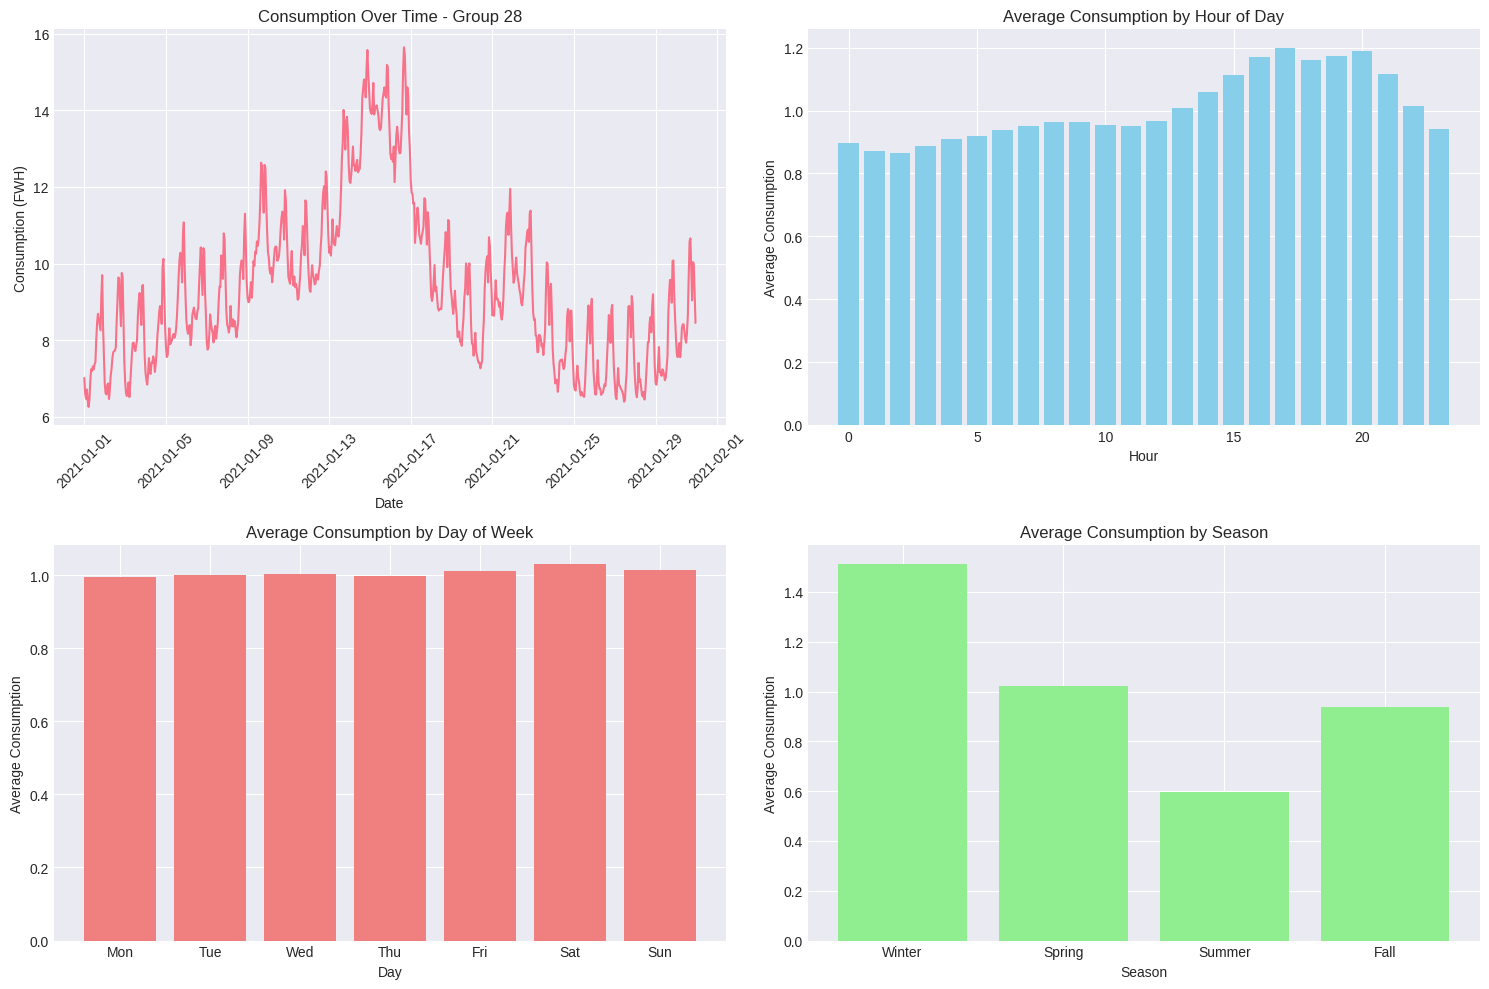

✅ Saved: temp_vs_consumption.png


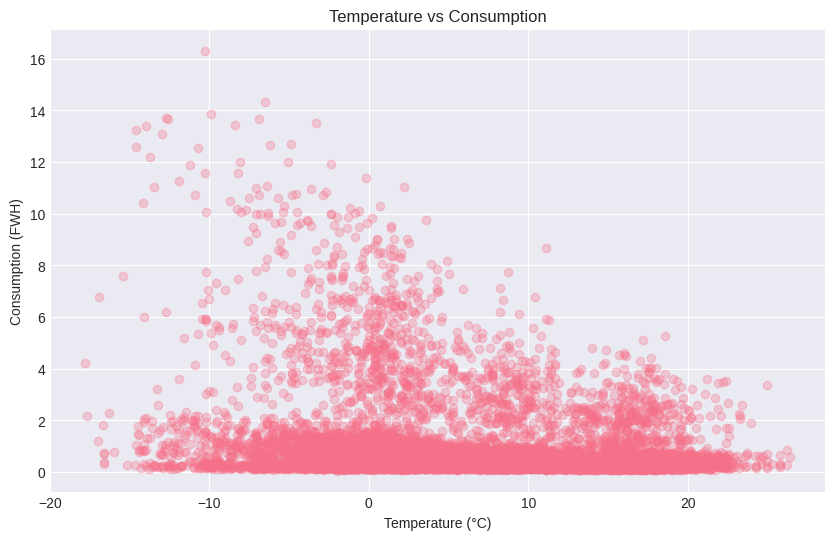

✅ Saved: price_vs_consumption.png


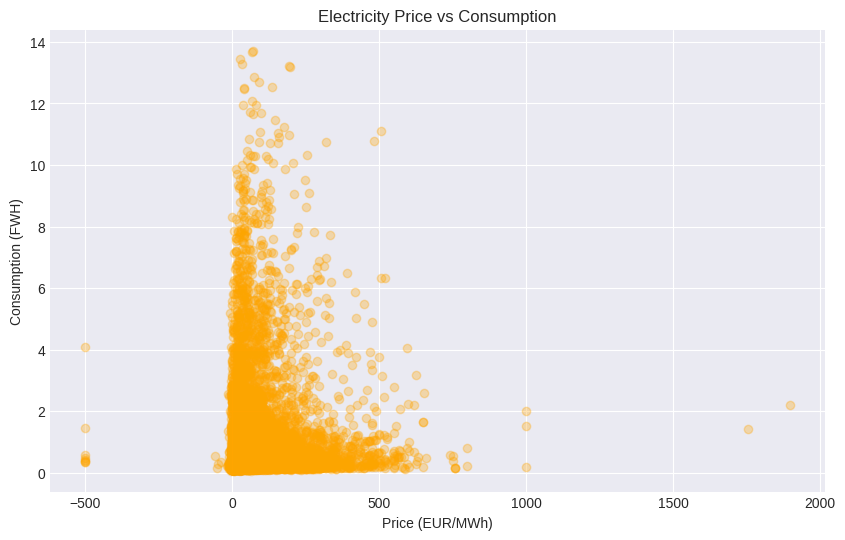

In [ ]:
# ============================================================================
# Step 23: Quick Visualizations
# ============================================================================
print("\n" + "="*80)
print("GENERATING VISUALIZATIONS")
print("="*80)

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# 1. Consumption over time for a sample group
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

sample_group = 28
sample_data = df[df['group_id'] == sample_group].iloc[:24*30]  # First 30 days

axes[0, 0].plot(sample_data['measured_at'], sample_data['consumption'])
axes[0, 0].set_title(f'Consumption Over Time - Group {sample_group}')
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Consumption (FWH)')
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. Average consumption by hour
hourly_avg = df.groupby('hour')['consumption'].mean()
axes[0, 1].bar(hourly_avg.index, hourly_avg.values, color='skyblue')
axes[0, 1].set_title('Average Consumption by Hour of Day')
axes[0, 1].set_xlabel('Hour')
axes[0, 1].set_ylabel('Average Consumption')

# 3. Average consumption by day of week
dow_avg = df.groupby('day_of_week')['consumption'].mean()
dow_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
axes[1, 0].bar(range(7), dow_avg.values, tick_label=dow_labels, color='lightcoral')
axes[1, 0].set_title('Average Consumption by Day of Week')
axes[1, 0].set_xlabel('Day')
axes[1, 0].set_ylabel('Average Consumption')

# 4. Consumption by season
season_avg = df.groupby('season')['consumption'].mean()
season_labels = ['Winter', 'Spring', 'Summer', 'Fall']
axes[1, 1].bar(range(4), season_avg.values, tick_label=season_labels, color='lightgreen')
axes[1, 1].set_title('Average Consumption by Season')
axes[1, 1].set_xlabel('Season')
axes[1, 1].set_ylabel('Average Consumption')

plt.tight_layout()
plt.savefig('consumption_patterns.png', dpi=300, bbox_inches='tight')
print("✅ Saved: consumption_patterns.png")
plt.show()

# 5. Temperature vs Consumption (if available)
if 'temperature' in df.columns:
    fig, ax = plt.subplots(figsize=(10, 6))
    sample = df.sample(10000)
    ax.scatter(sample['temperature'], sample['consumption'], alpha=0.3)
    ax.set_title('Temperature vs Consumption')
    ax.set_xlabel('Temperature (°C)')
    ax.set_ylabel('Consumption (FWH)')
    plt.savefig('temp_vs_consumption.png', dpi=300, bbox_inches='tight')
    print("✅ Saved: temp_vs_consumption.png")
    plt.show()

# 6. Price vs Consumption
fig, ax = plt.subplots(figsize=(10, 6))
sample = df.sample(10000)
ax.scatter(sample['eur_per_mwh'], sample['consumption'], alpha=0.3, color='orange')
ax.set_title('Electricity Price vs Consumption')
ax.set_xlabel('Price (EUR/MWh)')
ax.set_ylabel('Consumption (FWH)')
plt.savefig('price_vs_consumption.png', dpi=300, bbox_inches='tight')
print("✅ Saved: price_vs_consumption.png")
plt.show()

In [ ]:
# ============================================================================
# Step 24: Download Prepared Files
# ============================================================================
print("\n" + "="*80)
print("DOWNLOAD PREPARED FILES")
print("="*80)

'''print("📥 Downloading prepared files to your computer...")
files.download('fortum_prepared_full.parquet')
files.download('fortum_prepared_train.parquet')
files.download('fortum_prepared_val.parquet')
files.download('feature_list.json')
files.download('groups_metadata.csv')
files.download('encoders.pkl')'''

print("\n" + "="*80)
print("✅ DATA PREPARATION COMPLETE!")
print("="*80)
print("\n📋 Summary:")
print(f"   - Training data prepared: ✅")
print(f"   - Validation split created: ✅")
print(f"   - Features engineered: {len(all_features)}")
print(f"   - Weather data integrated: {'✅' if 'temperature' in df.columns else '❌'}")
print(f"   - Files saved: ✅")
print("\n🚀 Next steps:")
print("   1. Load the prepared data")
print("   2. Build and train models")
print("   3. Make predictions")
print("   4. Format and submit results")


DOWNLOAD PREPARED FILES

✅ DATA PREPARATION COMPLETE!

📋 Summary:
   - Training data prepared: ✅
   - Validation split created: ✅
   - Features engineered: 50
   - Weather data integrated: ✅
   - Files saved: ✅

🚀 Next steps:
   1. Load the prepared data
   2. Build and train models
   3. Make predictions
   4. Format and submit results


In [ ]:
df

,measured_at,group_id,consumption,eur_per_mwh,macro_region,county,municipality,segment,product_type,consumption_bucket,year,month,day,hour,day_of_week,day_of_year,week_of_year,is_weekend,is_night,hour_sin,hour_cos,dow_sin,dow_cos,month_sin,month_cos,season,is_holiday,holiday_name,daylight_hours,temperature,humidity,precipitation,wind_speed,cloud_cover,lag_1h,lag_24h,lag_48h,lag_168h,lag_336h,lag_8760h,price_lag_24h,price_lag_168h,rolling_mean_24h,rolling_std_24h,rolling_mean_168h,rolling_std_168h,rolling_mean_720h,rolling_std_720h,temp_squared,temp_x_hour,temp_x_is_weekend,hour_x_is_weekend,price_squared,price_x_temp,macro_region_encoded,county_encoded,municipality_encoded,segment_encoded,product_type_encoded,consumption_bucket_encoded
0,2021-01-01 00:00:00,28,7.010736,24.35,Eastern Finland,Etelä-Savo,Etelä-Savo,Private,Spot Price,High,2021,1,1,0,4,1,53,0,1,0.000000,1.000000,-0.433884,-0.900969,0.5,8.660254e-01,0,1,New Year's Day,5.98,1.8,96,0.0,12.6,81,4.713067,4.714494,4.715573,4.732092,4.752989,4.532834,55.665,55.965,4.774703,0.631878,4.795378,0.745864,4.877677,0.956719,3.24,0.0,0.0,0,592.9225,43.830,0,2,2,1,3,0
1,2021-01-01 01:00:00,28,6.600845,23.98,Eastern Finland,Etelä-Savo,Etelä-Savo,Private,Spot Price,High,2021,1,1,1,4,1,53,0,1,0.258819,0.965926,-0.433884,-0.900969,0.5,8.660254e-01,0,1,New Year's Day,5.98,2.0,94,0.0,8.3,85,7.010736,4.714494,4.715573,4.732092,4.752989,4.532834,55.665,55.965,7.010736,0.631878,7.010736,0.745864,7.010736,0.956719,4.00,2.0,0.0,0,575.0404,47.960,0,2,2,1,3,0
2,2021-01-01 02:00:00,28,6.468329,23.72,Eastern Finland,Etelä-Savo,Etelä-Savo,Private,Spot Price,High,2021,1,1,2,4,1,53,0,1,0.500000,0.866025,-0.433884,-0.900969,0.5,8.660254e-01,0,1,New Year's Day,5.98,0.8,97,0.0,8.2,80,6.600845,4.714494,4.715573,4.732092,4.752989,4.532834,55.665,55.965,6.805790,0.289837,6.805790,0.289837,6.805790,0.289837,0.64,1.6,0.0,0,562.6384,18.976,0,2,2,1,3,0
3,2021-01-01 03:00:00,28,6.712097,23.73,Eastern Finland,Etelä-Savo,Etelä-Savo,Private,Spot Price,High,2021,1,1,3,4,1,53,0,1,0.707107,0.707107,-0.433884,-0.900969,0.5,8.660254e-01,0,1,New Year's Day,5.98,1.3,96,0.0,7.7,97,6.468329,4.714494,4.715573,4.732092,4.752989,4.532834,55.665,55.965,6.693303,0.282776,6.693303,0.282776,6.693303,0.282776,1.69,3.9,0.0,0,563.1129,30.849,0,2,2,1,3,0
4,2021-01-01 04:00:00,28,6.418159,24.06,Eastern Finland,Etelä-Savo,Etelä-Savo,Private,Spot Price,High,2021,1,1,4,4,1,53,0,1,0.866025,0.500000,-0.433884,-0.900969,0.5,8.660254e-01,0,1,New Year's Day,5.98,2.1,94,0.0,9.7,100,6.712097,4.714494,4.715573,4.732092,4.752989,4.532834,55.665,55.965,6.698002,0.231077,6.698002,0.231077,6.698002,0.231077,4.41,8.4,0.0,0,578.8836,50.526,0,2,2,1,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3679867,2024-09-30 19:00:00,741,0.650630,4.19,Western and Inland Finland,Pohjanmaa,Pohjanmaa,Private,Variable Price,Medium,2024,9,30,19,0,274,40,0,0,-0.965926,0.258819,0.000000,1.000000,-1.0,-1.836970e-16,3,0,,11.49,10.7,62,0.0,7.1,0,0.639471,0.695166,0.676830,0.590031,0.546353,0.579974,11.340,15.760,0.608325,0.072511,0.550853,0.096998,0.476887,0.101118,114.49,203.3,0.0,0,17.5561,44.833,5,7,16,1,4,2
3679868,2024-09-30 20:00:00,741,0.604637,2.03,Western and Inland Finland,Pohjanmaa,Pohjanmaa,Private,Variable Price,Medium,2024,9,30,20,0,274,40,0,0,-0.866025,0.500000,0.000000,1.000000,-1.0,-1.836970e-16,3,0,,11.49,10.3,81,0.0,10.1,0,0.650630,0.625063,0.656772,0.515644,0.491412,0.555350,10.100,13.030,0.606469,0.070741,0.551214,0.097257,0.477049,0.101304,106.09,206.0,0.0,0,4.1209,20.909,5,7,16,1,4,2
3679869,2024-09-30 21:00:00,741,0.596577,0.00,Western and Inland Finland,Pohjanmaa,Pohjanmaa,Private,Variable Price,Medium,2024,9,30,21,0,274,40,0,0,-0.707107,0.707107,0.000000,1.000000,-1.0,-1.836970e-16,3,0,,11.49,10.7,71,0.0,12.4,0,0.604637,0.575196,0.603997,0.501564,0